In [ ]:
# --- INSTALL & IMPORT ---
#!pip install ultralytics pytesseract
#!sudo apt-get install tesseract-ocr
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import pytesseract
from ultralytics import YOLO

# --- LOAD MODELS ---
print("Loading models...")
# 1. Car Detection Model
car_model = YOLO('yolo11m.pt')

# 2. License Plate Model
license_model = YOLO('license-plate-finetune-v1m.pt')
plate_model = license_model

# 3. Seatbelt Model
seatbelt_model = YOLO('seatbelt_model.pt')

print("Models loaded successfully.")

Loading models...
Models loaded successfully.


In [2]:
# --- FUNCTION 1: DETECT CARS ---
def detect_cars(image_path):
    """Detects cars in an image and returns a list of cropped car images."""
    # Class 2=Car, 5=Bus, 7=Truck in COCO dataset
    results = car_model.predict(source=image_path, classes=[2, 5, 7], verbose=False)
    car_crops = []

    for result in results:
        for box in result.boxes.xyxy:
            x1, y1, x2, y2 = map(int, box.cpu().numpy())

            # Safe crop with bounds checking
            h, w = result.orig_img.shape[:2]
            y1, x1 = max(0, y1), max(0, x1)
            y2, x2 = min(h, y2), min(w, x2)

            crop = result.orig_img[y1:y2, x1:x2]
            if crop.size > 0:
                car_crops.append(crop)
    return car_crops

# --- FUNCTION 2: DETECT PLATES ---
def detect_license_plates(car_crops):
    """Detects license plates within car crops."""
    plate_crops = []
    for car in car_crops:
        results = license_model.predict(source=car, verbose=False)
        for result in results:
            for box in result.boxes.xyxy:
                x1, y1, x2, y2 = map(int, box.cpu().numpy())

                h, w = car.shape[:2]
                y1, x1 = max(0, y1), max(0, x1)
                y2, x2 = min(h, y2), min(w, x2)

                plate = car[y1:y2, x1:x2]
                if plate.size > 0:
                    plate_crops.append(plate)
    return plate_crops

# --- FUNCTION 3: READ TEXT (OCR) ---
def read_plate_text(plate_crops):
    """Reads text from license plate crops using Tesseract."""
    texts = []
    for plate in plate_crops:
        # Preprocessing: Grayscale + Otsu Thresholding
        gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Run OCR
        text = pytesseract.image_to_string(thresh, config='--psm 7')
        clean_text = ''.join(e for e in text if e.isalnum()) # Keep only letters/numbers
        texts.append(clean_text)
    return texts

In [ ]:
# --- CONFIGURATION ---
# Folder containing your images
dataset_folder = "/dataset" 
output_data = []

# Get all images
image_paths = glob.glob(os.path.join(dataset_folder, "*.*"))
image_paths = [p for p in image_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]

print(f"Processing {len(image_paths)} images...")

# --- PROCESSING LOOP ---
for img_path in image_paths:
    filename = os.path.basename(img_path)

    # 1. Detect Cars
    cars = detect_cars(img_path)

    if cars:
        # 2. Detect Plates
        plates = detect_license_plates(cars)

        if plates:
            # 3. Read Text
            texts = read_plate_text(plates)

            for t in texts:
                if t:
                    print(f"Found: {t} in {filename}")
                    output_data.append({"Image": filename, "Plate_Text": t})
        else:
            print(f"No plates in {filename}")
    else:
        print(f"No cars in {filename}")

# --- DISPLAY RESULTS ---
if output_data:
    df = pd.DataFrame(output_data)
    print("\n--- Final Results ---")
    print(df)
    # df.to_csv("license_plate_results.csv", index=False)
    # print("Saved to license_plate_results.csv")
else:
    print("No plates detected in the dataset.")

Processing 0 images...
No plates detected in the dataset.


Searching for cases to visualize (with Plate Crops)...
✅ Found Safe Case: 1625227980303_jpg.rf.5dabe03689408bb910be5fde8ce87973.jpg
🚨 Found Violation Case: 705_png_jpg.rf.17d47b396f1b9edcfa869d7132f27bfa.jpg


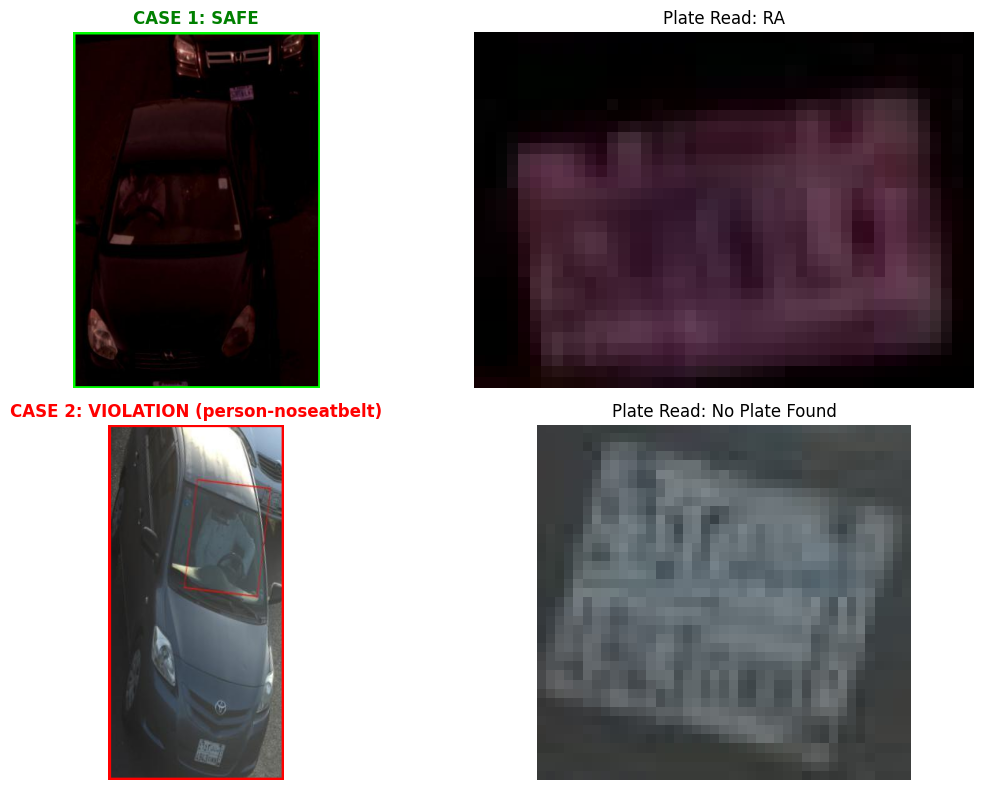

In [4]:
import matplotlib.pyplot as plt
import cv2
import glob
import os
import pytesseract
import numpy as np

# --- SETTINGS ---
images_path = "dataset/test/images"
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

found_safe = None      # Stores: (car_img, plate_crop, plate_text, status)
found_violation = None # Stores: (car_img, plate_crop, plate_text, status)

print("Searching for cases to visualize (with Plate Crops)...")

for img_file in glob.glob(os.path.join(images_path, "*.*")):
    if found_safe is not None and found_violation is not None:
        break
        
    image = cv2.imread(img_file)
    if image is None: continue
    
    # 1. Detect Car
    car_results = car_model.predict(image, classes=[2], verbose=False)
    
    for result in car_results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            car_crop = image[y1:y2, x1:x2]
            if car_crop.size == 0: continue

            # --- A. CHECK SEATBELT ---
            sb_results = seatbelt_model.predict(car_crop, verbose=False)
            status = "Unknown"
            color = (128, 128, 128)
            
            for sb_box in sb_results[0].boxes:
                cls_name = seatbelt_model.names[int(sb_box.cls[0])]
                conf = float(sb_box.conf[0])
                
                if conf > 0.4:
                    if cls_name in ['person-seatbelt', 'seatbelt', 'helmet']:
                        status = "SAFE"
                        color = (0, 255, 0) # Green
                    elif cls_name in ['person-noseatbelt', 'No-Seatbelt', 'no-seatbelt', 'mobile']:
                        status = f"VIOLATION ({cls_name})"
                        color = (0, 0, 255) # Red

            # --- B. CHECK LICENSE PLATE ---
            lp_results = plate_model.predict(car_crop, verbose=False)
            plate_crop_img = np.zeros((100, 300, 3), dtype=np.uint8) + 255 # White placeholder
            plate_text = "No Plate Found"
            
            if len(lp_results[0].boxes) > 0:
                best_plate = lp_results[0].boxes[0]
                px1, py1, px2, py2 = map(int, best_plate.xyxy[0])
                
                # Crop Plate from Car
                real_plate_crop = car_crop[py1:py2, px1:px2]
                if real_plate_crop.size > 0:
                    plate_crop_img = real_plate_crop
                    try:
                        gray_plate = cv2.cvtColor(plate_crop_img, cv2.COLOR_BGR2GRAY)
                        raw_text = pytesseract.image_to_string(gray_plate, config='--psm 7')
                        clean_text = "".join(c for c in raw_text if c.isalnum()).upper()
                        if clean_text: plate_text = clean_text
                    except:
                        plate_text = "OCR Error"

            # --- C. STORE RESULT ---
            # Annotate Car Image
            annotated_car = car_crop.copy()
            cv2.rectangle(annotated_car, (0, 0), (annotated_car.shape[1], annotated_car.shape[0]), color, 5)
            
            # Save data
            data_bundle = (annotated_car, plate_crop_img, plate_text, status)
            
            if status == "SAFE" and found_safe is None:
                found_safe = data_bundle
                print(f"✅ Found Safe Case: {os.path.basename(img_file)}")
            elif "VIOLATION" in status and found_violation is None:
                found_violation = data_bundle
                print(f"🚨 Found Violation Case: {os.path.basename(img_file)}")

# --- VISUALIZE 2x2 GRID ---
if found_safe or found_violation:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # ROW 1: SAFE CASE
    if found_safe:
        # Car Image
        axes[0,0].imshow(cv2.cvtColor(found_safe[0], cv2.COLOR_BGR2RGB))
        axes[0,0].set_title(f"CASE 1: {found_safe[3]}", color='green', fontweight='bold')
        axes[0,0].axis('off')
        # Plate Crop
        axes[0,1].imshow(cv2.cvtColor(found_safe[1], cv2.COLOR_BGR2RGB))
        axes[0,1].set_title(f"Plate Read: {found_safe[2]}", fontsize=12)
        axes[0,1].axis('off')
    
    # ROW 2: VIOLATION CASE
    if found_violation:
        # Car Image
        axes[1,0].imshow(cv2.cvtColor(found_violation[0], cv2.COLOR_BGR2RGB))
        axes[1,0].set_title(f"CASE 2: {found_violation[3]}", color='red', fontweight='bold')
        axes[1,0].axis('off')
        # Plate Crop
        axes[1,1].imshow(cv2.cvtColor(found_violation[1], cv2.COLOR_BGR2RGB))
        axes[1,1].set_title(f"Plate Read: {found_violation[2]}", fontsize=12)
        axes[1,1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Could not find suitable images.")

Scanning through 410 images for random examples...
🚨 Found Violation Case: 792_png_jpg.rf.2f84d56c94acb5bb5d3ebfda1ae772d1.jpg
✅ Found Safe Case: 204_jpg.rf.5c7d2a655a35402531cce0b4eb759e00.jpg


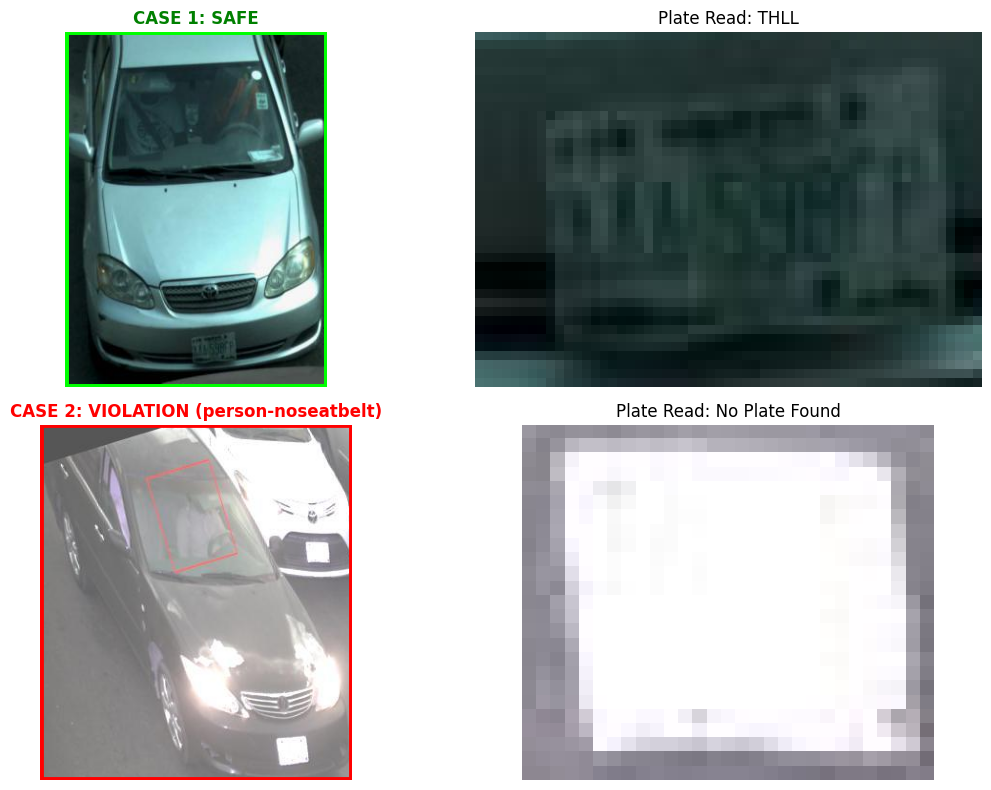

In [5]:
import matplotlib.pyplot as plt
import cv2
import glob
import os
import pytesseract
import numpy as np
import random

# --- SETTINGS ---
images_path = "dataset/test/images"
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

found_safe = None      # Stores: (car_img, plate_crop, plate_text, status)
found_violation = None # Stores: (car_img, plate_crop, plate_text, status)

# 1. GET ALL IMAGES & SHUFFLE THEM
all_images = glob.glob(os.path.join(images_path, "*.*"))
random.shuffle(all_images)  # <--- THIS MAKES IT RANDOM EVERY TIME

print(f"Scanning through {len(all_images)} images for random examples...")

for img_file in all_images:
    # Stop if we found both a Safe AND a Violation case
    if found_safe is not None and found_violation is not None:
        break
        
    image = cv2.imread(img_file)
    if image is None: continue
    
    # 2. Detect Car
    car_results = car_model.predict(image, classes=[2], verbose=False)
    
    for result in car_results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            car_crop = image[y1:y2, x1:x2]
            if car_crop.size == 0: continue

            # --- A. CHECK SEATBELT ---
            sb_results = seatbelt_model.predict(car_crop, verbose=False)
            status = "Unknown"
            color = (128, 128, 128)
            
            for sb_box in sb_results[0].boxes:
                cls_name = seatbelt_model.names[int(sb_box.cls[0])]
                conf = float(sb_box.conf[0])
                
                if conf > 0.4:
                    if cls_name in ['person-seatbelt', 'seatbelt', 'helmet']:
                        status = "SAFE"
                        color = (0, 255, 0) # Green
                    elif cls_name in ['person-noseatbelt', 'No-Seatbelt', 'no-seatbelt', 'mobile']:
                        status = f"VIOLATION ({cls_name})"
                        color = (0, 0, 255) # Red

            # --- B. CHECK LICENSE PLATE ---
            lp_results = plate_model.predict(car_crop, verbose=False)
            plate_crop_img = np.zeros((100, 300, 3), dtype=np.uint8) + 255 # White placeholder
            plate_text = "No Plate Found"
            
            if len(lp_results[0].boxes) > 0:
                best_plate = lp_results[0].boxes[0]
                px1, py1, px2, py2 = map(int, best_plate.xyxy[0])
                
                # Crop Plate from Car
                real_plate_crop = car_crop[py1:py2, px1:px2]
                if real_plate_crop.size > 0:
                    plate_crop_img = real_plate_crop
                    try:
                        gray_plate = cv2.cvtColor(plate_crop_img, cv2.COLOR_BGR2GRAY)
                        raw_text = pytesseract.image_to_string(gray_plate, config='--psm 7')
                        clean_text = "".join(c for c in raw_text if c.isalnum()).upper()
                        if clean_text: plate_text = clean_text
                    except:
                        plate_text = "OCR Error"

            # --- C. STORE RESULT ---
            # Annotate Car Image
            annotated_car = car_crop.copy()
            cv2.rectangle(annotated_car, (0, 0), (annotated_car.shape[1], annotated_car.shape[0]), color, 5)
            
            # Save data
            data_bundle = (annotated_car, plate_crop_img, plate_text, status)
            
            if status == "SAFE" and found_safe is None:
                found_safe = data_bundle
                print(f"✅ Found Safe Case: {os.path.basename(img_file)}")
            elif "VIOLATION" in status and found_violation is None:
                found_violation = data_bundle
                print(f"🚨 Found Violation Case: {os.path.basename(img_file)}")

# --- VISUALIZE 2x2 GRID ---
if found_safe or found_violation:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # ROW 1: SAFE CASE
    if found_safe:
        # Car Image
        axes[0,0].imshow(cv2.cvtColor(found_safe[0], cv2.COLOR_BGR2RGB))
        axes[0,0].set_title(f"CASE 1: {found_safe[3]}", color='green', fontweight='bold')
        axes[0,0].axis('off')
        # Plate Crop
        axes[0,1].imshow(cv2.cvtColor(found_safe[1], cv2.COLOR_BGR2RGB))
        axes[0,1].set_title(f"Plate Read: {found_safe[2]}", fontsize=12)
        axes[0,1].axis('off')
    else:
        axes[0,0].text(0.5, 0.5, "No Safe Case Found", ha='center')
        axes[0,1].axis('off')
    
    # ROW 2: VIOLATION CASE
    if found_violation:
        # Car Image
        axes[1,0].imshow(cv2.cvtColor(found_violation[0], cv2.COLOR_BGR2RGB))
        axes[1,0].set_title(f"CASE 2: {found_violation[3]}", color='red', fontweight='bold')
        axes[1,0].axis('off')
        # Plate Crop
        axes[1,1].imshow(cv2.cvtColor(found_violation[1], cv2.COLOR_BGR2RGB))
        axes[1,1].set_title(f"Plate Read: {found_violation[2]}", fontsize=12)
        axes[1,1].axis('off')
    else:
        axes[1,0].text(0.5, 0.5, "No Violation Case Found", ha='center')
        axes[1,1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Could not find suitable images.")